# Body Fat Percentage Estimation Using Unsupervised Learning

This notebook estimates body fat percentage from a folder of unlabeled body images using a CNN-based autoencoder for feature extraction and K-Means clustering to group similar body types. The clusters can be mapped to body fat percentage ranges with domain knowledge.

## Step 1: Import Libraries

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.cluster import KMeans
from PIL import Image
import glob
import matplotlib.pyplot as plt
%matplotlib inline

## Step 2: Load and Preprocess Images

Load images from a folder, resize them to 128x128 pixels, and normalize pixel values to [0, 1]. Replace `folder_path` with the path to your image folder.

In [3]:
import numpy as np
from PIL import Image
import glob
import os

def load_images_and_masks(image_folder, mask_folder):
    images = []
    masks = []
    image_files = glob.glob(f"{image_folder}/*.png") + glob.glob(f"{image_folder}/*.jpg")
    mask_files = glob.glob(f"{mask_folder}/*.png") + glob.glob(f"{mask_folder}/*.jpg")
    
    # Create a dictionary of mask filenames (stripping the "Mask_" prefix) for quick lookup
    mask_dict = {}
    for mask_path in mask_files:
        mask_filename = os.path.basename(mask_path)
        original_filename = mask_filename.replace("Mask_", "")  # Remove "Mask_" prefix
        mask_dict[original_filename] = mask_path
    
    for img_path in image_files:
        try:
            # Extract filename without extension for matching
            filename = os.path.basename(img_path)
            if filename in mask_dict:
                mask_path = mask_dict[filename]
                
                # Load and preprocess image
                img = Image.open(img_path).convert('RGB').resize((128, 128))
                img_array = np.array(img)
                
                # Load and preprocess mask (convert to grayscale and normalize)
                mask = Image.open(mask_path).convert('L').resize((128, 128))  # 'L' for grayscale
                mask_array = np.array(mask).astype('float32') / 255.0  # Normalize to [0, 1]
                mask_array = np.expand_dims(mask_array, axis=-1)  # Add channel dimension
                
                if img_array.shape == (128, 128, 3) and mask_array.shape == (128, 128, 1):
                    images.append(img_array)
                    masks.append(mask_array)
                else:
                    print(f"Skipping {img_path}: Image shape {img_array.shape}, Mask shape {mask_array.shape}")
            else:
                print(f"No matching mask found for {img_path}")
        except Exception as e:
            print(f"Error loading {img_path} or its mask: {e}")
            continue
    
    images = np.array(images).astype('float32') / 255.0  # Normalize images
    masks = np.array(masks).astype('float32')  # Masks already normalized
    if images.size == 0 or masks.size == 0:
        raise ValueError("No valid image-mask pairs found in the specified folders.")
    print(f"Images array shape: {images.shape}")
    print(f"Masks array shape: {masks.shape}")
    return images, masks

# Updated folder paths
image_folder = r"E:\assignment (9th sem)\CAP II\Image Dataset\Image_train"
mask_folder = r"E:\assignment (9th sem)\CAP II\Image Dataset\Image_train_mask"
images, masks = load_images_and_masks(image_folder, mask_folder)
print(f"Loaded {len(images)} image-mask pairs")

Images array shape: (2349, 128, 128, 3)
Masks array shape: (2349, 128, 128, 1)
Loaded 2349 image-mask pairs


## Step 3: Build CNN Autoencoder

Create a CNN autoencoder to extract latent features from images.

In [4]:
def build_autoencoder():
    input_shape = (128, 128, 3)  # Image input
    mask_input_shape = (128, 128, 1)  # Mask input
    
    # Encoder inputs
    image_input = layers.Input(shape=input_shape)
    mask_input = layers.Input(shape=mask_input_shape)
    
    # Concatenate image and mask along the channel axis
    x = layers.Concatenate()([image_input, mask_input])  # Shape becomes (128, 128, 4)
    
    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)
    
    # Decoder
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)  # Output only image
    
    # Autoencoder model
    autoencoder = models.Model([image_input, mask_input], decoded)
    
    # Encoder model for feature extraction
    encoder = models.Model([image_input, mask_input], encoded)
    
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder

## Step 4: Train Autoencoder and Extract Features

Train the autoencoder and use the encoder to extract latent features.

In [5]:
def train_and_extract_features(images, masks, epochs=10):
    if len(images.shape) != 4 or images.shape[1:] != (128, 128, 3):
        raise ValueError(f"Expected images shape (num_images, 128, 128, 3), got {images.shape}")
    if len(masks.shape) != 4 or masks.shape[1:] != (128, 128, 1):
        raise ValueError(f"Expected masks shape (num_images, 128, 128, 1), got {masks.shape}")
    autoencoder, encoder = build_autoencoder()
    batch_size = min(32, len(images))
    autoencoder.fit([images, masks], images, epochs=epochs, batch_size=batch_size, verbose=1)
    latent_features = encoder.predict([images, masks], batch_size=batch_size)
    latent_features = latent_features.reshape(len(images), -1)  # Flatten for clustering
    return latent_features

latent_features = train_and_extract_features(images, masks, epochs=20)
print(f"Extracted latent features with shape {latent_features.shape}")

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 42s 510ms/step - loss: 0.0300
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 36s 486ms/step - loss: 0.0115
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 42s 561ms/step - loss: 0.0086
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 39s 527ms/step - loss: 0.0074
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 40s 534ms/step - loss: 0.0066
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 45s 608ms/step - loss: 0.0062
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 94s 773ms/step - loss: 0.0059
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 43s 587ms/step - loss: 0.0054
Epoch 9/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 80s 557ms/step - loss: 0.0052
Epoch 10/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 44s 600ms/step - loss: 0.0055
Epoch 11/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 43s 582ms/step - loss: 0.0047
Epoch 12/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 42s 560ms/step - loss: 0.0046
Epoch 13/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 55s 750ms/step - loss: 0.0044
Epoch 14/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 41s 550ms/step - loss: 0.0043
Epoch 15/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 38s 

## Step 5: Cluster Latent Features

Use K-Means to cluster the latent features into groups, which may correspond to body fat percentage ranges.

In [6]:
def cluster_features(latent_features, n_clusters=5):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(latent_features)
    return clusters

n_clusters = 5
clusters = cluster_features(latent_features, n_clusters)
print("Cluster assignments for each image:", clusters)

Cluster assignments for each image: [1 1 1 ... 1 4 3]


## Step 6: Visualize Results

Display a few images from each cluster to inspect the groupings.

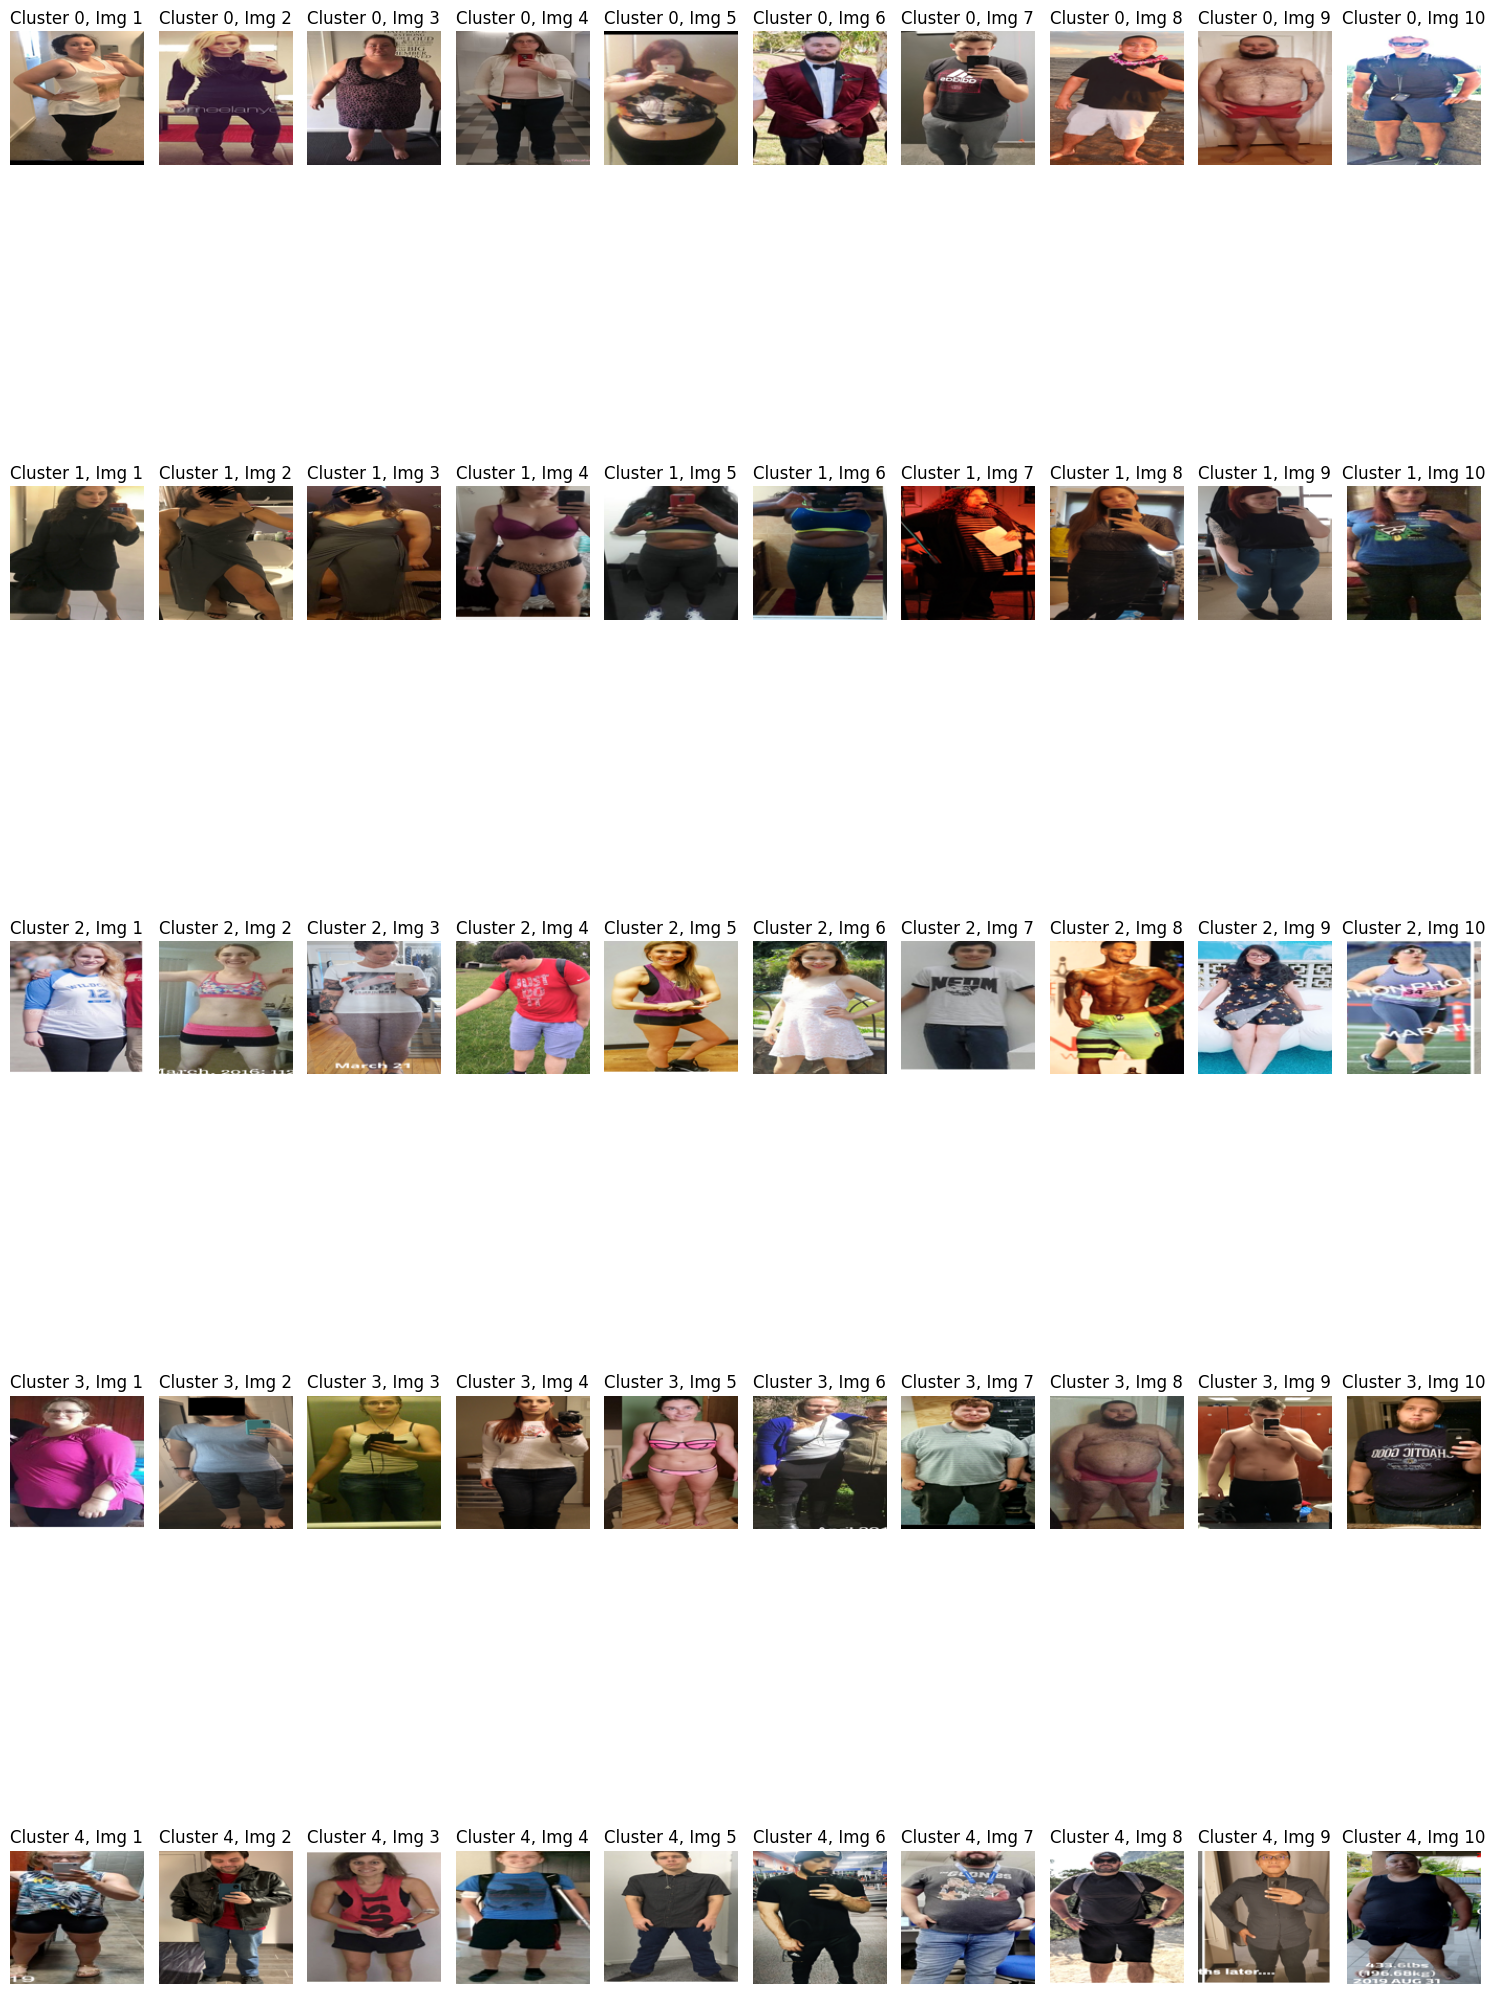

In [7]:
def visualize_clusters(images, clusters, n_clusters, max_images_per_cluster=10):
    plt.figure(figsize=(15, 5 * n_clusters))  # Adjust figure size based on number of clusters
    for cluster_id in range(n_clusters):
        cluster_indices = np.where(clusters == cluster_id)[0]
        if len(cluster_indices) > 0:
            num_images_to_show = min(max_images_per_cluster, len(cluster_indices))  # Limit to 10 or available images
            for i in range(num_images_to_show):
                plt.subplot(n_clusters, max_images_per_cluster, cluster_id * max_images_per_cluster + i + 1)
                plt.imshow(images[cluster_indices[i]])
                plt.title(f"Cluster {cluster_id}, Img {i+1}")
                plt.axis('off')
    plt.tight_layout()
    plt.show()

# Use the previously defined n_clusters from the clustering step
n_clusters = 5  # Replace with the actual number of clusters used in your KMeans (e.g., from Cell 5)
visualize_clusters(images, clusters, n_clusters)

## Step 7: Map Clusters to Body Fat Ranges

Map clusters to hypothetical body fat percentage ranges. This requires domain knowledge or manual labeling.

In [8]:
body_fat_ranges = ["<15%", "15-20%", "20-25%", "25-30%", ">30%"]
for i, cluster in enumerate(clusters):
    print(f"Image {i+1} assigned to cluster {cluster} (Estimated body fat: {body_fat_ranges[cluster]})")

Image 1 assigned to cluster 1 (Estimated body fat: 15-20%)
Image 2 assigned to cluster 1 (Estimated body fat: 15-20%)
Image 3 assigned to cluster 1 (Estimated body fat: 15-20%)
Image 4 assigned to cluster 1 (Estimated body fat: 15-20%)
Image 5 assigned to cluster 1 (Estimated body fat: 15-20%)
Image 6 assigned to cluster 1 (Estimated body fat: 15-20%)
Image 7 assigned to cluster 1 (Estimated body fat: 15-20%)
Image 8 assigned to cluster 3 (Estimated body fat: 25-30%)
Image 9 assigned to cluster 1 (Estimated body fat: 15-20%)
Image 10 assigned to cluster 0 (Estimated body fat: <15%)
Image 11 assigned to cluster 3 (Estimated body fat: 25-30%)
Image 12 assigned to cluster 3 (Estimated body fat: 25-30%)
Image 13 assigned to cluster 0 (Estimated body fat: <15%)
Image 14 assigned to cluster 2 (Estimated body fat: 20-25%)
Image 15 assigned to cluster 1 (Estimated body fat: 15-20%)
Image 16 assigned to cluster 1 (Estimated body fat: 15-20%)
Image 17 assigned to cluster 3 (Estimated body fat: 2

## Notes

- **Image Folder**: Replace `folder_path` with the actual path to your image folder.
- **Cluster Interpretation**: Clusters may not directly map to body fat percentages. Validate with domain expertise or label a subset of images.
- **Tuning**: Adjust `n_clusters`, `epochs`, or the autoencoder architecture based on your dataset.
- **Visualization**: The visualization shows one representative image per cluster. Inspect multiple images per cluster for better understanding.